<a href="https://colab.research.google.com/github/Fruce/Insurance-Fraud/blob/main/Insurance_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# necessary imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv("sample_data/insurance_claims.csv")

In [ ]:
#only authorities_contacted has missing values
df.isna().sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [ ]:
#filling up the missing values with most occuring value of the column
df['authorities_contacted'] = df['authorities_contacted'].fillna(df['authorities_contacted'].mode()[0])

In [ ]:
df.isna().sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [ ]:
# dropping columns which are not necessary for prediction

to_drop = ['policy_number','policy_bind_date','policy_state','insured_zip','incident_location','incident_date',
           'incident_state','incident_city','insured_hobbies','auto_make','auto_model','auto_year', '_c39']

df.drop(to_drop, inplace = True, axis = 1)

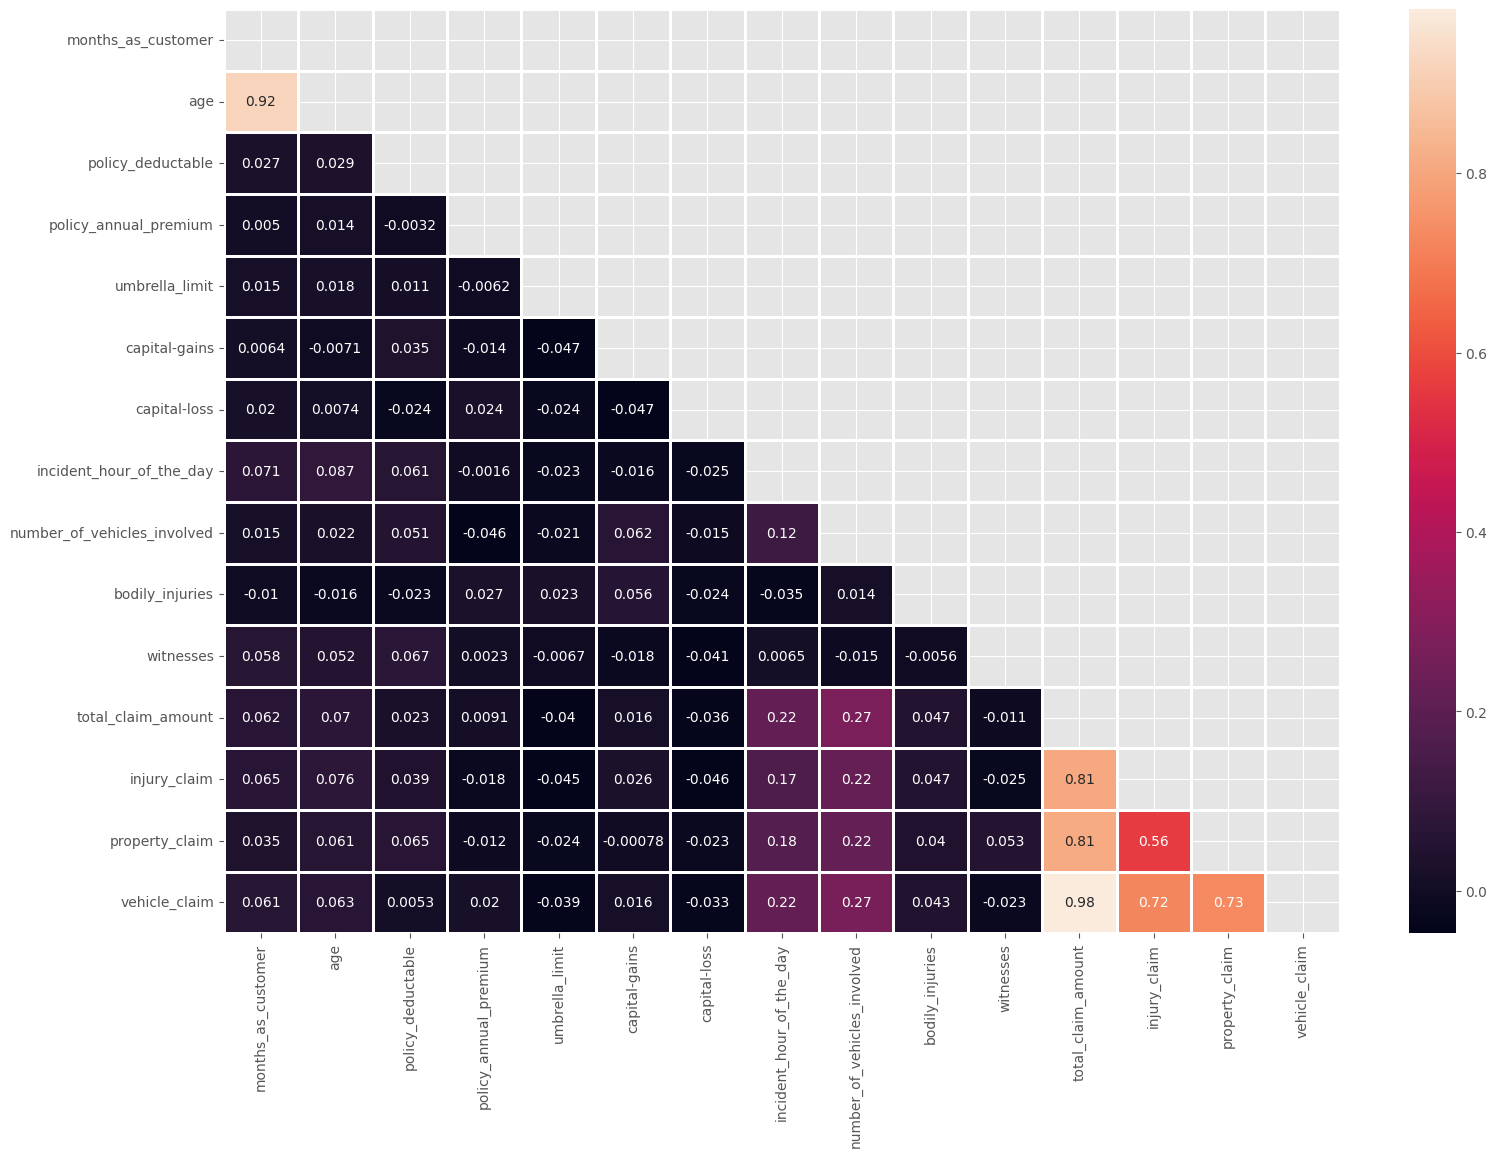

In [ ]:
# checking for multicollinearity

plt.figure(figsize = (18, 12))

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(data = corr, mask = mask, annot = True, fmt = '.2g', linewidth = 1)
plt.show()

From the above plot, we can see that there is high correlation between age and months_as_customer.We will drop the "Age" column. Also there is high correlation between total_clam_amount, injury_claim, property_claim, vehicle_claim as total claim is the sum of all others. So we will drop the total claim column.

In [ ]:
#dropping two more columns for multicollinearity
df.drop(columns = ['age', 'total_claim_amount'], inplace = True, axis = 1)


In [ ]:
df.head()


,months_as_customer,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_relationship,capital-gains,...,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,injury_claim,property_claim,vehicle_claim,fraud_reported
0,328,250/500,1000,1406.91,0,MALE,MD,craft-repair,husband,53300,...,5,1,YES,1,2,YES,6510,13020,52080,Y
1,228,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,other-relative,0,...,8,1,?,0,0,?,780,780,3510,Y
2,134,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,own-child,35100,...,7,3,NO,2,3,NO,7700,3850,23100,N
3,256,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,unmarried,48900,...,5,1,?,1,2,NO,6340,6340,50720,Y
4,228,500/1000,1000,1583.91,6000000,MALE,Associate,sales,unmarried,66000,...,20,1,NO,0,1,NO,1300,650,4550,N


Handling Outliers

In [ ]:
IQR = []

IQR.append(df['months_as_customer'].quantile(0.75) - df['months_as_customer'].quantile(0.25))
IQR.append(df['policy_annual_premium'].quantile(0.75) - df['policy_annual_premium'].quantile(0.25))
IQR.append(df['umbrella_limit'].quantile(0.75) - df['umbrella_limit'].quantile(0.25))
IQR.append(df['property_claim'].quantile(0.75) - df['property_claim'].quantile(0.25))

IQR

[np.float64(160.5),
 np.float64(326.0875000000001),
 np.float64(0.0),
 np.float64(6440.0)]

In [ ]:
upper = []

upper.append(df['months_as_customer'].quantile(0.75) + 1.5 * (IQR[0]))
upper.append(df['policy_annual_premium'].quantile(0.75) + 1.5 * (IQR[1]))
upper.append(df['umbrella_limit'].quantile(0.75) + 1.5 * (IQR[2]))
upper.append(df['property_claim'].quantile(0.75) + 1.5 * (IQR[3]))

months_as_customer


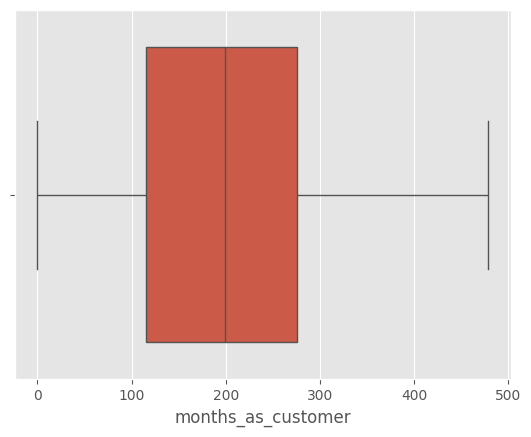

policy_deductable


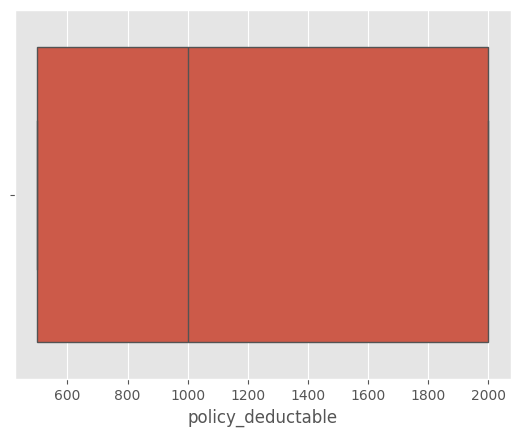

policy_annual_premium


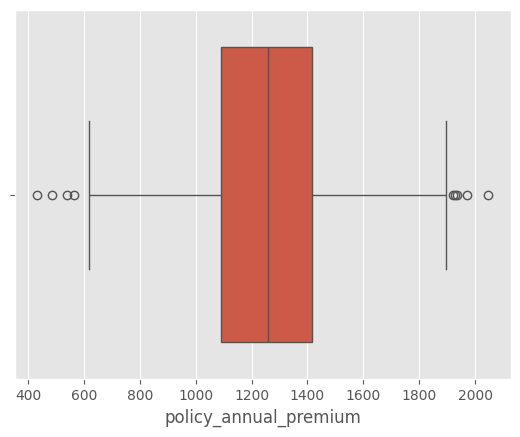

umbrella_limit


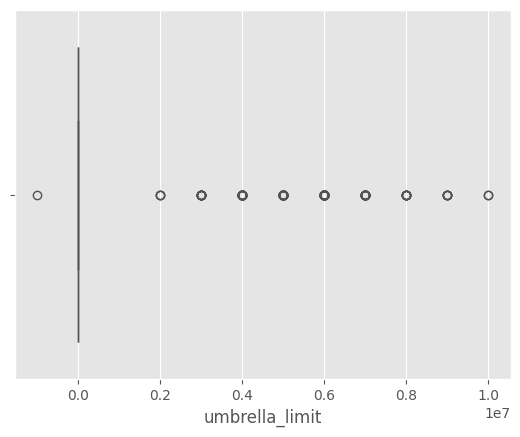

capital-gains


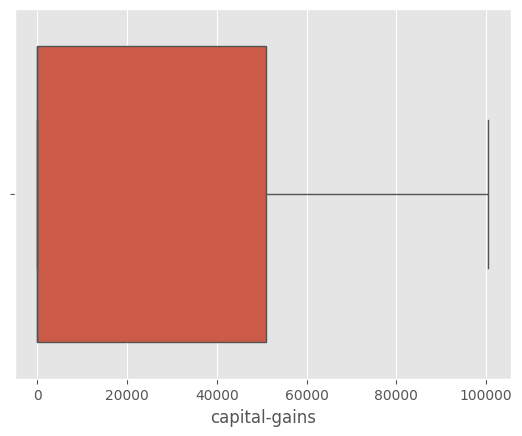

capital-loss


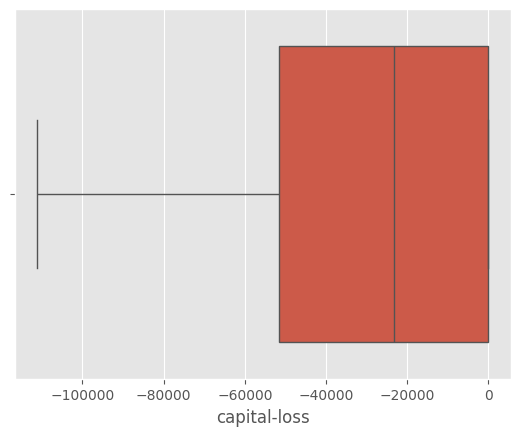

incident_hour_of_the_day


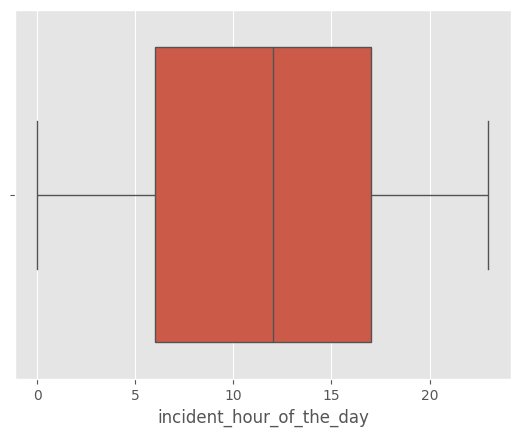

number_of_vehicles_involved


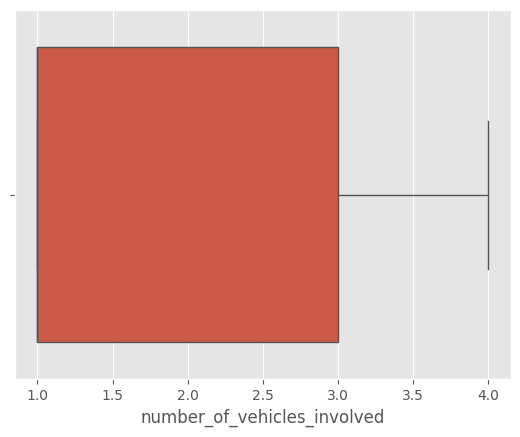

bodily_injuries


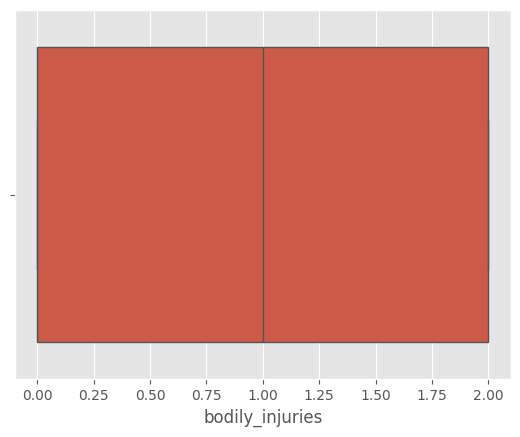

witnesses


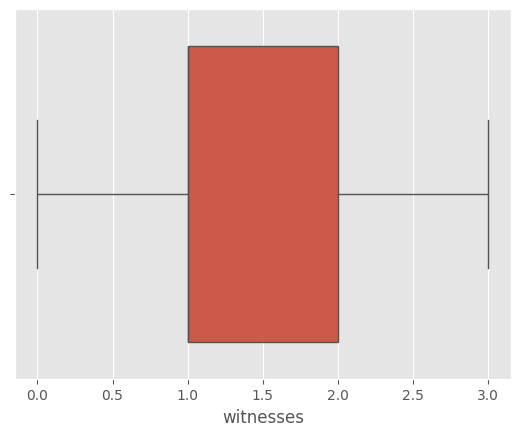

injury_claim


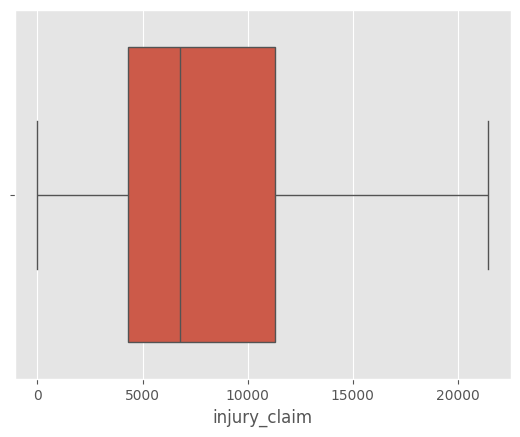

property_claim


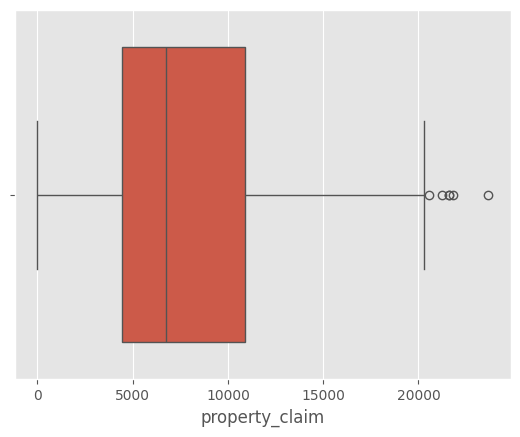

vehicle_claim


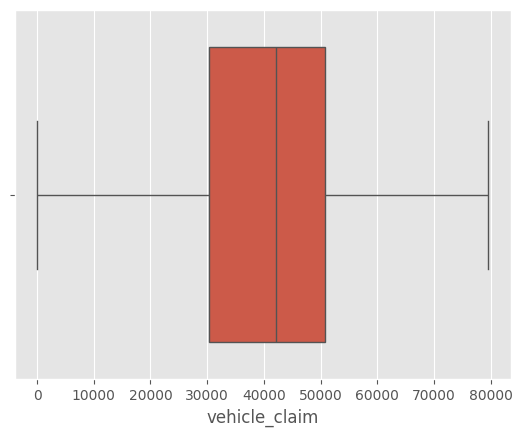

In [ ]:
df_num_features = df.select_dtypes(include=np.number)

for k in df_num_features.columns:
    print(k)
    sns.boxplot(data=df, x=k)
    plt.show()

In [ ]:
# separating the feature and target columns

X = df.drop('fraud_reported', axis = 1)
y = df['fraud_reported']

In [ ]:
# Extract Categorical Columns
cat_df = X.select_dtypes(include=['object'])

In [ ]:
# Inspect unique categories

for col in cat_df.columns:
    print(f"{col}:\n{cat_df[col].unique()}\n")

policy_csl:
['250/500' '100/300' '500/1000']

insured_sex:
['MALE' 'FEMALE']

insured_education_level:
['MD' 'PhD' 'Associate' 'Masters' 'High School' 'College' 'JD']

insured_occupation:
['craft-repair' 'machine-op-inspct' 'sales' 'armed-forces' 'tech-support'
 'prof-specialty' 'other-service' 'priv-house-serv' 'exec-managerial'
 'protective-serv' 'transport-moving' 'handlers-cleaners' 'adm-clerical'
 'farming-fishing']

insured_relationship:
['husband' 'other-relative' 'own-child' 'unmarried' 'wife' 'not-in-family']

incident_type:
['Single Vehicle Collision' 'Vehicle Theft' 'Multi-vehicle Collision'
 'Parked Car']

collision_type:
['Side Collision' '?' 'Rear Collision' 'Front Collision']

incident_severity:
['Major Damage' 'Minor Damage' 'Total Loss' 'Trivial Damage']

authorities_contacted:
['Police' 'Fire' 'Other' 'Ambulance']

property_damage:
['YES' '?' 'NO']

police_report_available:
['YES' '?' 'NO']



In [ ]:
# One-Hot Encode Categorical Features
cat_df = pd.get_dummies(cat_df, drop_first=True)

In [ ]:
# Extract Numerical Columns
num_df = X.select_dtypes(include=['int64', 'float64'])

In [ ]:
# Combine Numerical and Categorical Data
X = pd.concat([num_df, cat_df], axis=1)

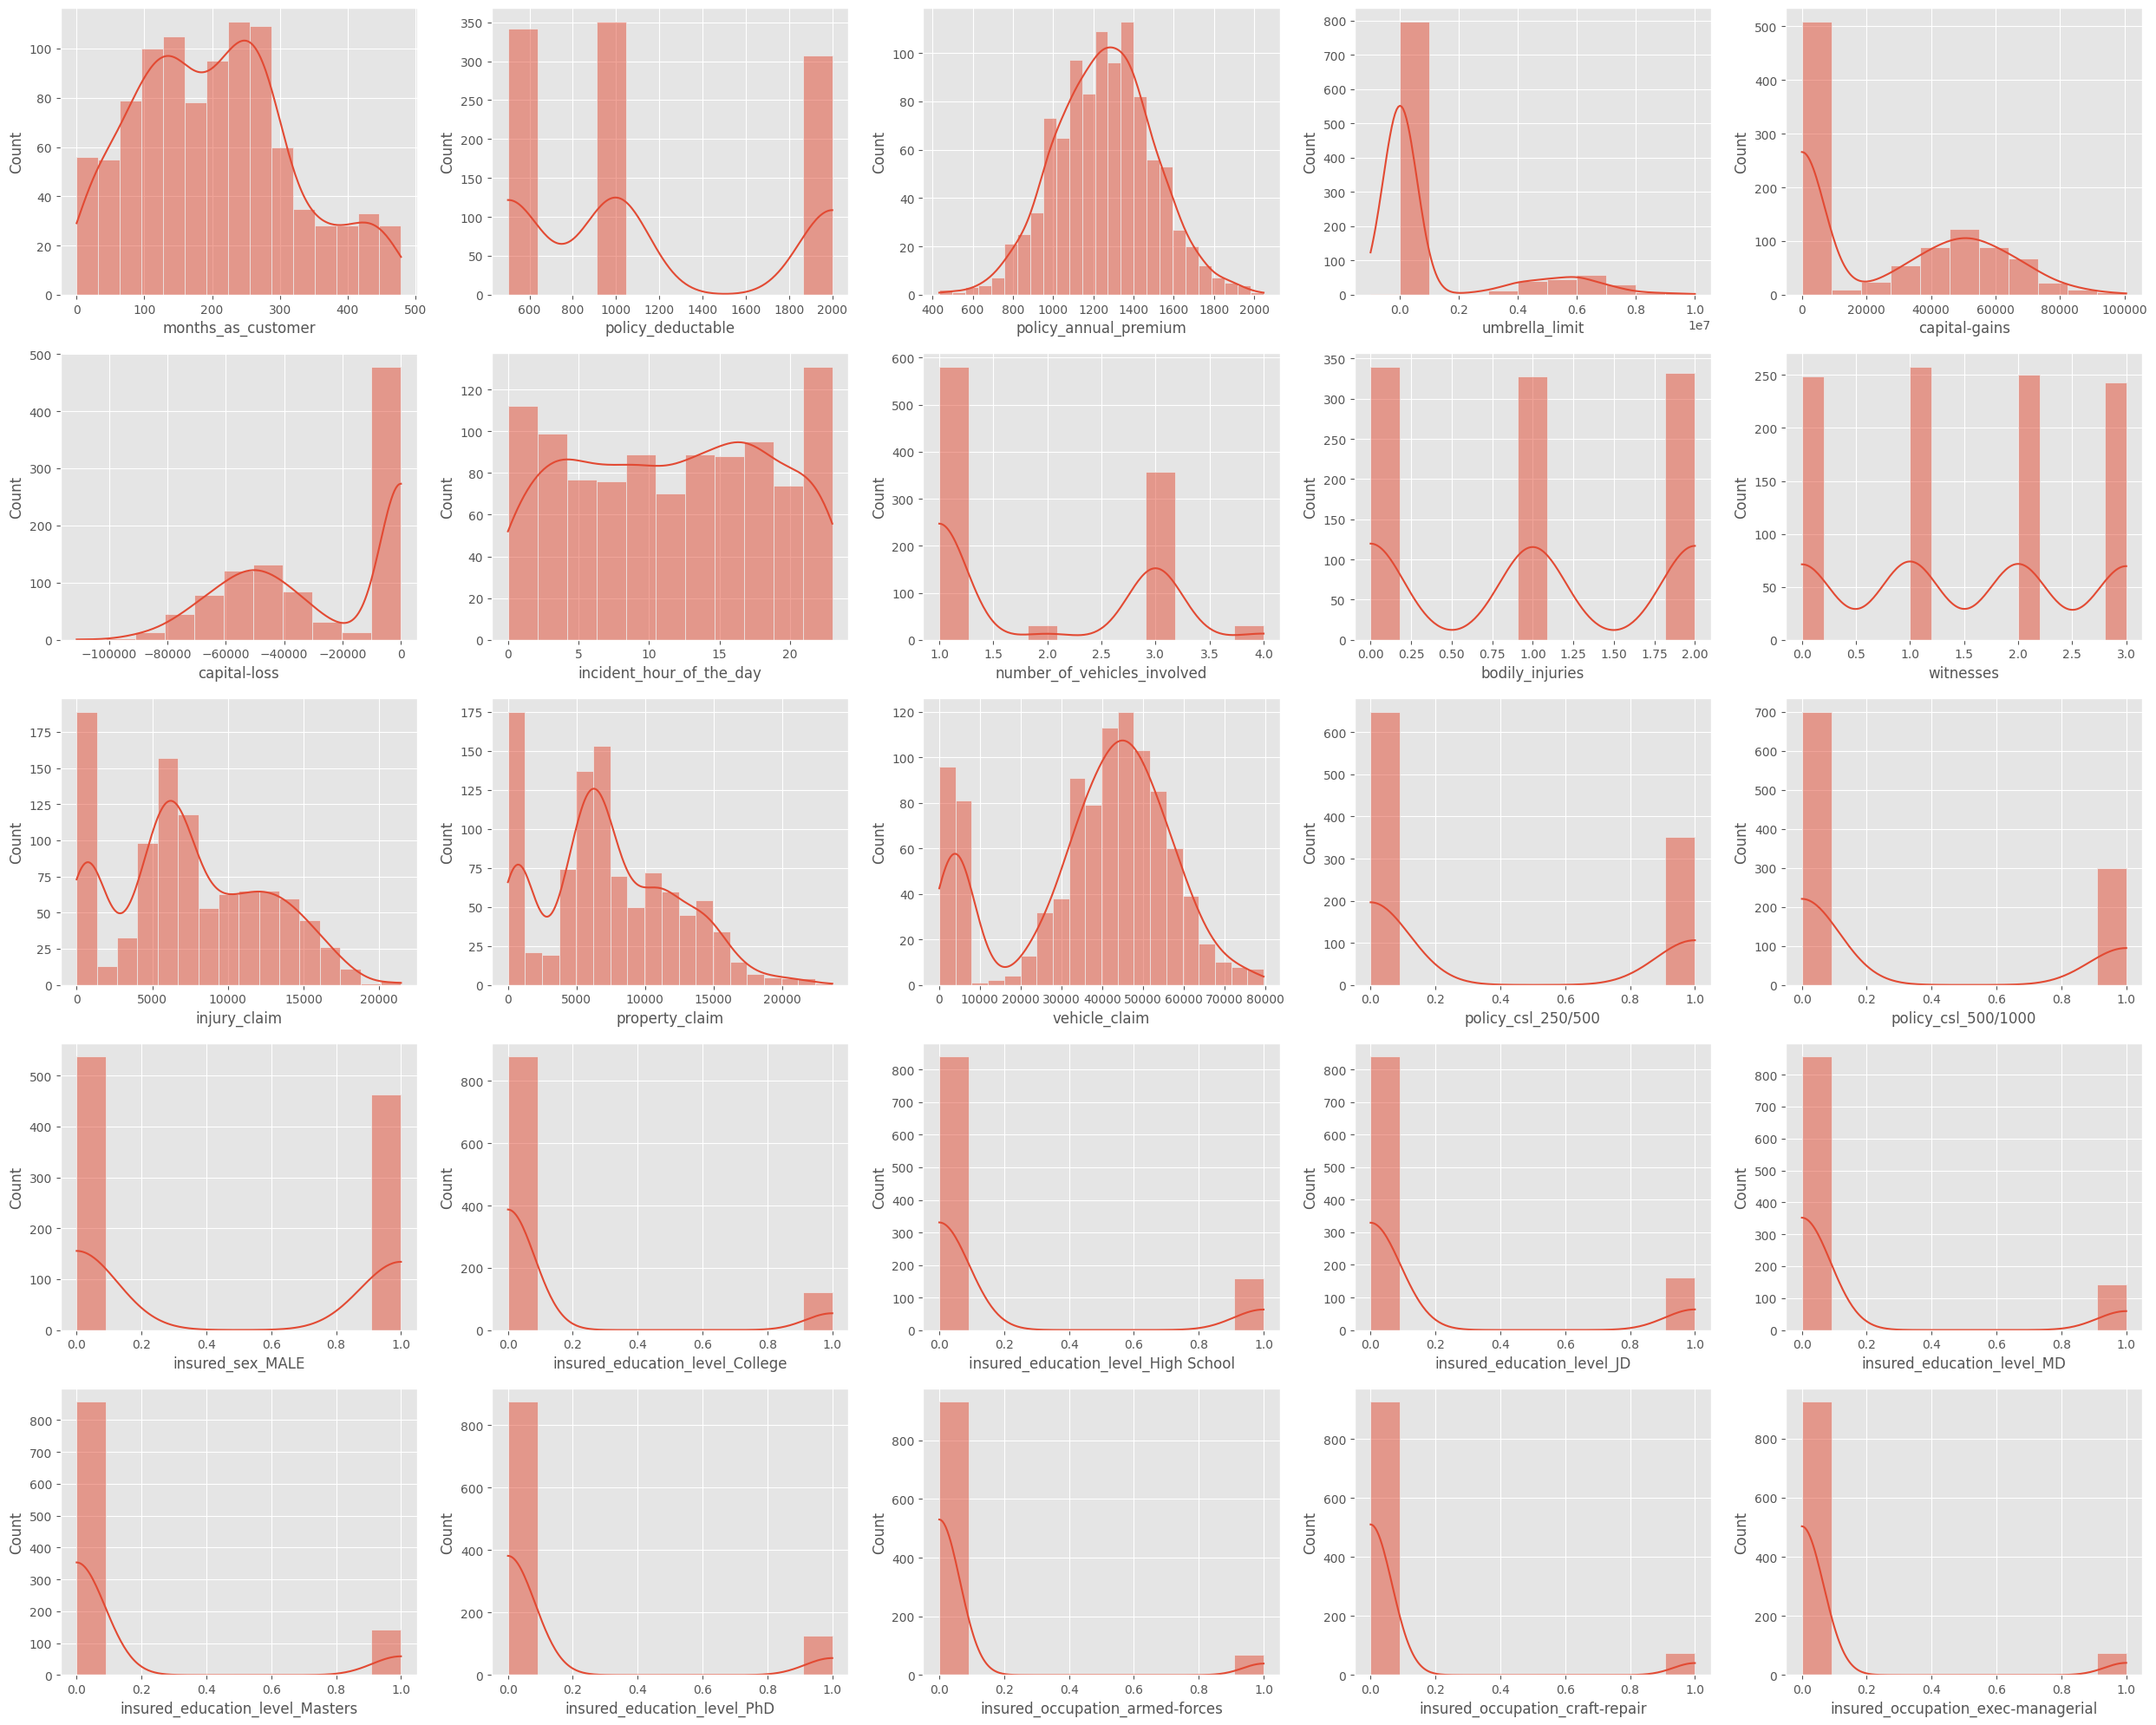

In [ ]:
# Visualize feature distributions
plt.figure(figsize=(25, 20))
plotnumber = 1

for col in X.columns:
    if plotnumber <= 25:
        plt.subplot(5, 5, plotnumber)
        sns.histplot(X[col], kde=True)
        plt.xlabel(col, fontsize=12)
    plotnumber += 1

plt.tight_layout()
plt.show()

In [ ]:
#Train - Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.head()

,months_as_customer,policy_deductable,policy_annual_premium,umbrella_limit,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,...,incident_severity_Minor Damage,incident_severity_Total Loss,incident_severity_Trivial Damage,authorities_contacted_Fire,authorities_contacted_Other,authorities_contacted_Police,property_damage_NO,property_damage_YES,police_report_available_NO,police_report_available_YES
29,241,2000,1104.50,0,0,0,5,1,2,2,...,True,False,False,False,False,True,True,False,True,False
535,65,1000,1099.95,0,0,-71900,14,1,1,0,...,False,False,False,False,True,False,True,False,False,True
695,289,2000,1221.41,0,46700,-72500,9,1,2,1,...,False,False,True,False,False,True,True,False,True,False
557,63,500,1500.04,6000000,0,-36500,5,1,0,2,...,True,False,False,False,False,True,True,False,False,True
836,257,1000,974.84,0,52100,0,0,1,0,1,...,False,True,False,False,False,True,True,False,False,True
